In [1]:
# 第3章｜實做 SVM 選股：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 實做 SVM 選股

**對應影片**：第 3 章 單元 3、4「實做 SVM 選股 Part 1、Part 2」（觀念請看單元 2「SVM」）

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| `ml.fundamental_features()` 產生特徵、`ml.add_profit_prediction()` 加上報酬 | `finlab.ml.feature.combine` 組合特徵、`finlab.ml.label` 計算報酬 |
| 隨機切訓練集與測試集 | 依時間切：用過去訓練、用之後的資料測試，才不會「偷看未來」 |
| 用 `mlxtend` 畫決策邊界 | 用 scikit-learn 內建的 `DecisionBoundaryDisplay` |
| 回測只比較兩組平均報酬 | 另外用 `sim()` 做含交易成本的回測 |

目標：只用 **ROE** 和 **營業毛利成長率** 兩個財報指標，讓 SVM 判斷一支股票下一季會不會贏過大部分股票。

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import finlab.ml.feature as feature
import finlab.ml.label as label
from finlab.backtest import sim
from finlab.dataframe import FinlabDataFrame
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

REBALANCE = 'QE'           # 每季最後一天重新選股
TRAIN_END = '2016-12-31'   # 之前的資料用來訓練，之後的資料用來測試
RANDOM_STATE = 0

## 1. 準備特徵

`feature.combine` 把多張「日期 × 股票」的表，整理成機器學習用的長表：每一列是（日期, 股票），每一欄是一個特徵。
`resample='QE'` 代表只取每季最後一天，當時看得到的最新財報數字。

In [3]:
FEATURES = {'roe': 'ROE稅後', 'gross_margin_growth': '營業毛利成長率'}

dataset = feature.combine(
    {column: data.get(f'fundamental_features:{name}') for column, name in FEATURES.items()},
    resample=REBALANCE,
)
dataset.dropna().tail()

roe  gross_margin_growth
datetime   instrument                               
2019-03-31 9951        4.326864            -9.858529
           9955       -9.705608          -194.802330
           9958        0.181123           574.185193
           9960        1.269591             9.665581
           9962        3.549325           199.568437

## 2. 加上答案（label）

- `return`：隔天買進、持有到下一季的報酬率。
- `beat_median`：報酬率是否高於同一季所有股票的中位數，這就是 SVM 要預測的答案。

In [4]:
dataset['return'] = label.return_percentage(dataset.index, resample=REBALANCE)
dataset['beat_median'] = label.excess_over_median(dataset.index, resample=REBALANCE) > 0
dataset = dataset.dropna()
dataset.tail()

roe  gross_margin_growth    return  beat_median
datetime   instrument                                                      
2018-09-30 9951        3.749526            -6.225215 -0.062722         True
           9955       -1.568343            59.259721 -0.135714        False
           9958        0.142250            48.044902 -0.297297        False
           9960        3.306507            23.728762  0.043333         True
           9962        2.954825          1340.990047 -0.008658         True

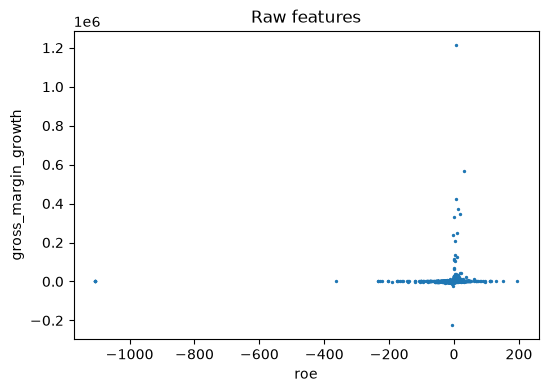

In [5]:
dataset.plot.scatter('roe', 'gross_margin_growth', s=2, figsize=(6, 4), title='Raw features');

## 3. 去除極端值

財報指標常有極端值（例如營收很小的公司，成長率動輒幾千 %），會讓模型只顧著遷就少數怪異的點。
把每個特徵最小與最大的 5% 去掉。

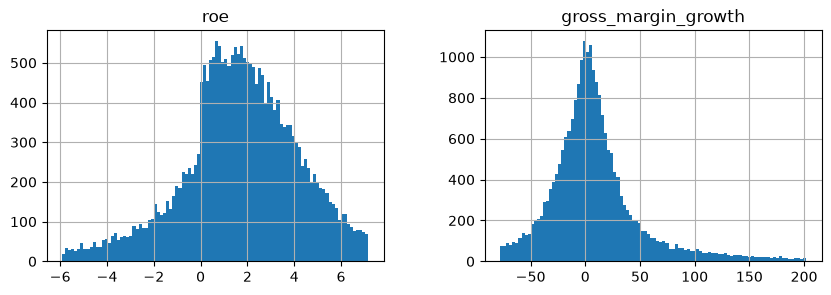

In [6]:
OUTLIER_QUANTILE = 0.05

feature_columns = list(FEATURES)
lower = dataset[feature_columns].quantile(OUTLIER_QUANTILE)
upper = dataset[feature_columns].quantile(1 - OUTLIER_QUANTILE)
dataset = dataset[((dataset[feature_columns] >= lower) & (dataset[feature_columns] <= upper)).all(axis=1)]

dataset[feature_columns].hist(bins=100, figsize=(10, 3));

## 4. 切分訓練與測試資料、標準化

SVM 對特徵的尺度很敏感，所以要標準化成平均 0、標準差 1。
標準化的平均與標準差**只能用訓練資料計算**，測試資料套用同樣的轉換。

In [7]:
dates = dataset.index.get_level_values('datetime')
train, test = dataset[dates <= TRAIN_END], dataset[dates > TRAIN_END]

scaler = StandardScaler().fit(train[feature_columns])
X_train, X_test = scaler.transform(train[feature_columns]), scaler.transform(test[feature_columns])
y_train, y_test = train['beat_median'], test['beat_median']
print(f'訓練資料 {len(train):,} 筆、測試資料 {len(test):,} 筆')

訓練資料 13,293 筆、測試資料 9,218 筆


## 5. 訓練 SVM

SVM 的訓練時間會隨資料量快速增加（大約是資料量的平方），所以從訓練資料中隨機抽 `SVM_TRAIN_SAMPLES` 筆來訓練。

In [8]:
SVM_TRAIN_SAMPLES = 5_000

sample = train.sample(n=min(SVM_TRAIN_SAMPLES, len(train)), random_state=RANDOM_STATE)
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(scaler.transform(sample[feature_columns]), sample['beat_median'])

print(f'訓練資料準確率：{model.score(X_train, y_train):.2%}')
print(f'測試資料準確率：{model.score(X_test, y_test):.2%}')

訓練資料準確率：53.67%


測試資料準確率：53.21%


選股模型的準確率通常只比 50% 高一點：股價很難預測，但只要穩定地比丟銅板好一點，長期累積就有差別。

### 決策邊界

背景顏色是 SVM 的判斷（黃色 = 會贏過中位數、紫色 = 不會），點是測試資料的真實答案（紅 = 真的贏過中位數、藍 = 沒有）。

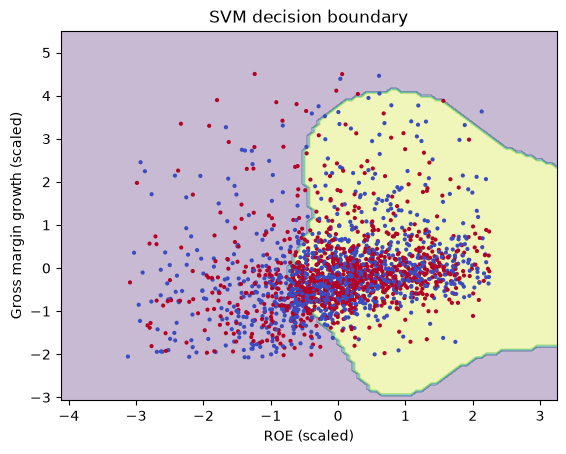

In [9]:
PLOT_SAMPLES = 2_000

plot_index = test.sample(n=min(PLOT_SAMPLES, len(test)), random_state=RANDOM_STATE).index
plot_X = scaler.transform(test.loc[plot_index, feature_columns])

boundary = DecisionBoundaryDisplay.from_estimator(model, plot_X, response_method='predict', alpha=0.3)
boundary.ax_.scatter(plot_X[:, 0], plot_X[:, 1], c=test.loc[plot_index, 'beat_median'], s=4, cmap='coolwarm')
boundary.ax_.set(xlabel='ROE (scaled)', ylabel='Gross margin growth (scaled)', title='SVM decision boundary');

## 6. 回測

### 6-1 兩組平均報酬

每一季把股票分成「SVM 說會贏」與「SVM 說會輸」兩組，比較兩組的平均報酬。

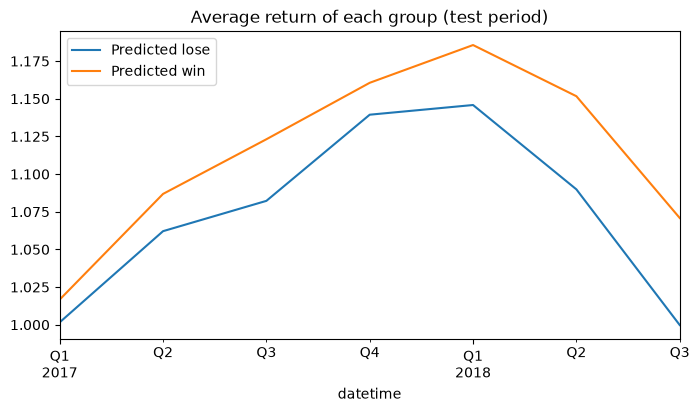

In [10]:
test = test.assign(prediction=model.predict(X_test), score=model.decision_function(X_test))
test_dates = test.index.get_level_values('datetime')

group_return = test.groupby([test_dates, 'prediction'])['return'].mean().unstack('prediction')
group_return.columns = ['Predicted lose', 'Predicted win']
(1 + group_return).cumprod().plot(figsize=(8, 4), title='Average return of each group (test period)');

### 6-2 用 `sim()` 回測：每季買 SVM 最有信心的 30 檔

`decision_function` 是離決策邊界的距離，越大代表 SVM 越有信心。每季挑分數最高的 `N_STOCKS` 檔等權重持有。
`sim()` 會計入手續費與交易稅。

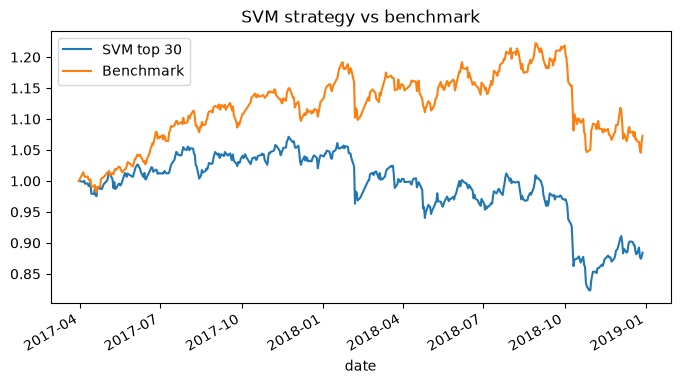

In [11]:
N_STOCKS = 30

score = FinlabDataFrame(test['score'].unstack('instrument'))
report = sim(score.is_largest(N_STOCKS), name='SVM')

curves = pd.DataFrame({'SVM top 30': report.creturn})
benchmark = report.benchmark.reindex(curves.index)
curves['Benchmark'] = benchmark / benchmark.dropna().iloc[0]
curves.plot(figsize=(8, 4), title='SVM strategy vs benchmark');

In [12]:
{key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}

{'cagr': -0.06817504329949331,
 'max_drawdown': -0.2316837439420758,
 'daily_sharpe': -0.6181969638145365}

試試看：

- 換成 `kernel='linear'`（影片用的設定），決策邊界和回測結果有什麼不同？
- 換成其他兩個財報指標（可用的指標見第 2 章「常用財報指標」）。